In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

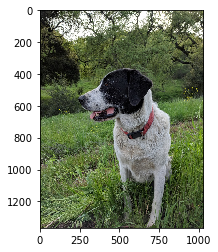

In [2]:
img_full = cv2.imread("DATA/sammy.jpg")
img_full = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB)

plt.imshow(img_full)

In [3]:
img_full.shape

(1367, 1025, 3)

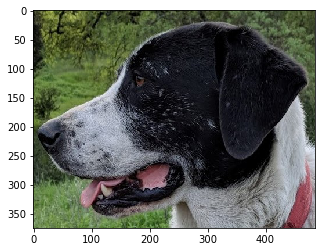

In [4]:
img_face = cv2.imread("DATA/sammy_face.jpg")
img_face = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)
plt.imshow(img_face)

In [5]:
img_face.shape

(375, 486, 3)

# Knowing eval()

In [6]:
sum([1,2,3])  # OK

6

In [7]:
myString = 'sum'
# myString([1,2,3])  # NOT OK

In [8]:
# so
myString = 'sum'
eval(myString)  # Evaluate by eval function

<function sum(iterable, start=0, /)>

In [9]:
myFunc = eval(myString)
myFunc([1,2,3])  # Now can use

6

 # Move to the topic

In [10]:
# list all methods for iterate over all methods using the eval function
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

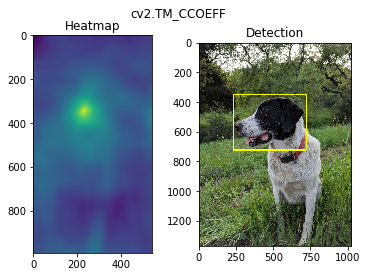

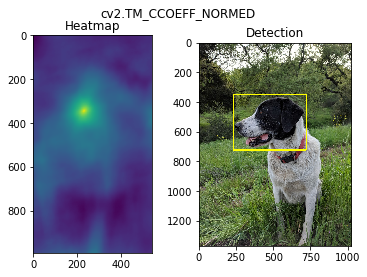

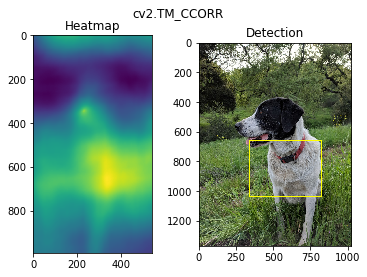

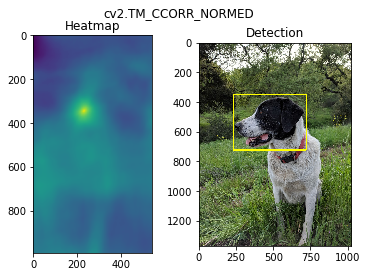

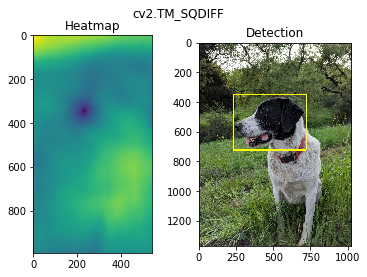

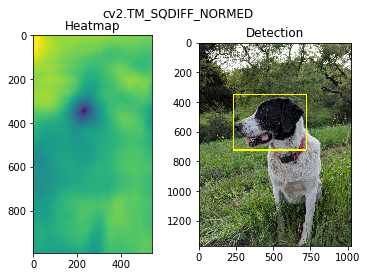

In [22]:
for m in methods:
    img_full_copy = img_full.copy()
    
    method = eval(m)
    
    res = cv2.matchTemplate(img_full_copy, img_face, method)
    
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
        
        
    height, width, shape = img_face.shape
    
    bottom_right = (top_left[0]+width, top_left[1]+height)
    
#     print(top_left)
#     print(bottom_right,'\n')
    
    cv2.rectangle(img_full_copy, top_left, bottom_right, (255, 255, 0), 5)
    
    # plot and show the images
    plt.subplot(121)
    plt.imshow(res)
    plt.title('Heatmap')
    
    plt.subplot(122)
    plt.imshow(img_full_copy)
    plt.title('Detection')
    
    plt.suptitle(m)
    
    plt.show()
    

In [12]:
res.shape

(993, 540)

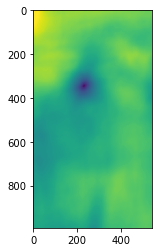

In [13]:
img_full_copy = img_full.copy()
    
method = eval('cv2.TM_SQDIFF_NORMED')
res = cv2.matchTemplate(img_full_copy, img_face, method)

plt.imshow(res)

In [14]:
res.shape

(993, 540)